In [1]:
#install.packages('caret') # split train-test data
#install.packages('PRROC') # precision-recall curve
#install.packages('Metrics') #Fbeta score
#install.packages("randomForest")
#install.packages('mdatools') # PLS-DA
#install.packages("LiblineaR")
#install.packages('e1071') 

In [1]:
library(tidyverse)

Warning message:
"package 'ggplot2' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
data <- read.csv("cardiovascular_disease_data.csv")
head(data)
summary(data)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

In [3]:
data$Gender = as.factor(data$Gender)
data$Smoking_Status = as.factor(data$Smoking_Status)
data$Alcohol_Consumption = as.factor(data$Alcohol_Consumption)
data$Physical_Activity_Level = as.factor(data$Physical_Activity_Level)
data$Family_History = as.factor(data$Family_History)
data$Stress_Level = as.factor(data$Stress_Level)
data$Sleep_Hours = as.factor(data$Sleep_Hours)
data$Heart_Disease_Risk = as.factor(data$Heart_Disease_Risk)

In [4]:
# change patient ID to index

data = data %>% column_to_rownames(., var="Patient_ID")

In [5]:
summary(data)

      Age        Gender     Height_cm       Weight_kg           BMI       
 Min.   :25.00   0:7622   Min.   :138.5   Min.   : 33.70   Min.   :14.50  
 1st Qu.:46.00   1:7378   1st Qu.:158.5   1st Qu.: 65.20   1st Qu.:24.50  
 Median :55.00            Median :164.7   Median : 73.90   Median :27.20  
 Mean   :54.54            Mean   :165.3   Mean   : 75.25   Mean   :27.45  
 3rd Qu.:63.00            3rd Qu.:172.0   3rd Qu.: 83.90   3rd Qu.:30.00  
 Max.   :85.00            Max.   :198.1   Max.   :150.10   Max.   :46.10  
                                                                          
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0     3rd Qu.:

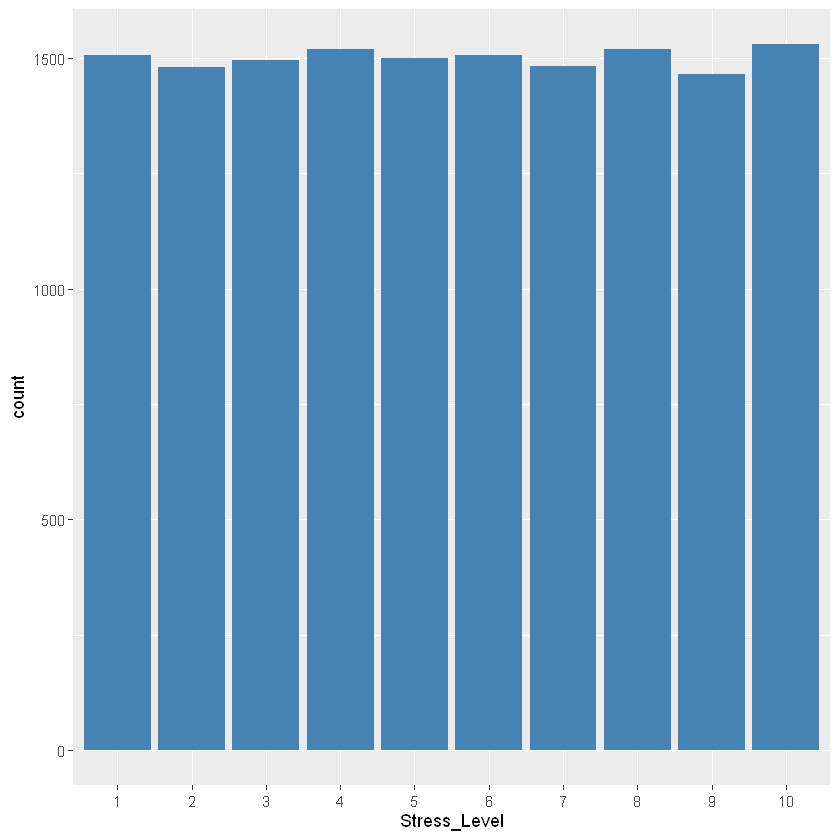

In [6]:
ggplot(data = data, aes(x=Stress_Level)) + geom_bar(stat = 'count', fill="steelblue")

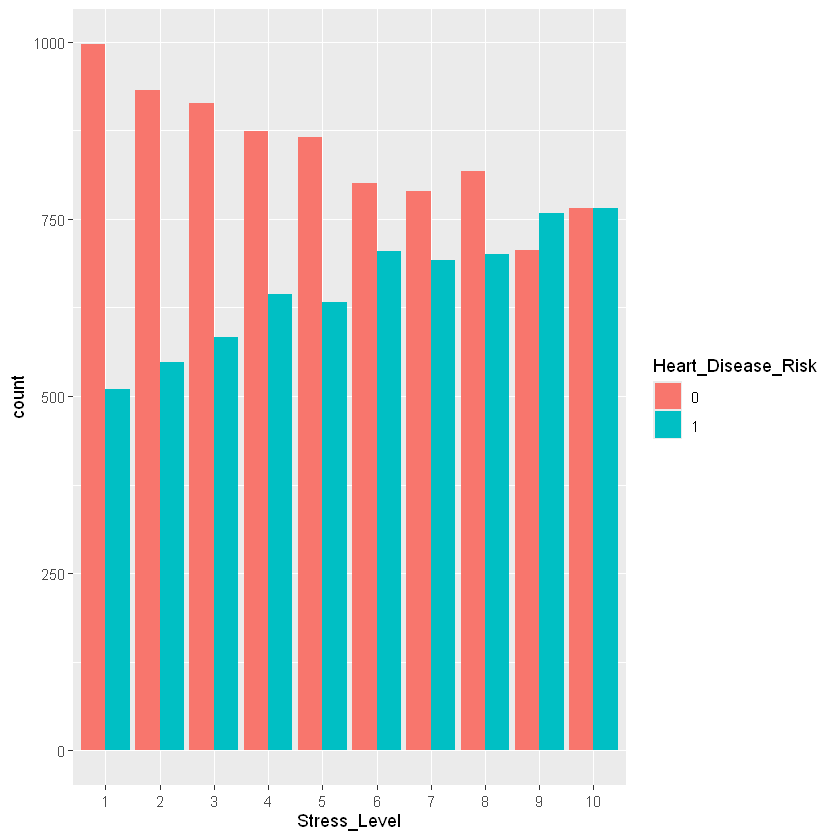

In [7]:
ggplot(data = data, aes(x=Stress_Level, fill=Heart_Disease_Risk))+ geom_bar(stat = 'count', position=position_dodge())

In [8]:
data$Stress_Level = as.numeric(data$Stress_Level)

**Comment** Lineear relation, so treating stress_level as quantitative still works

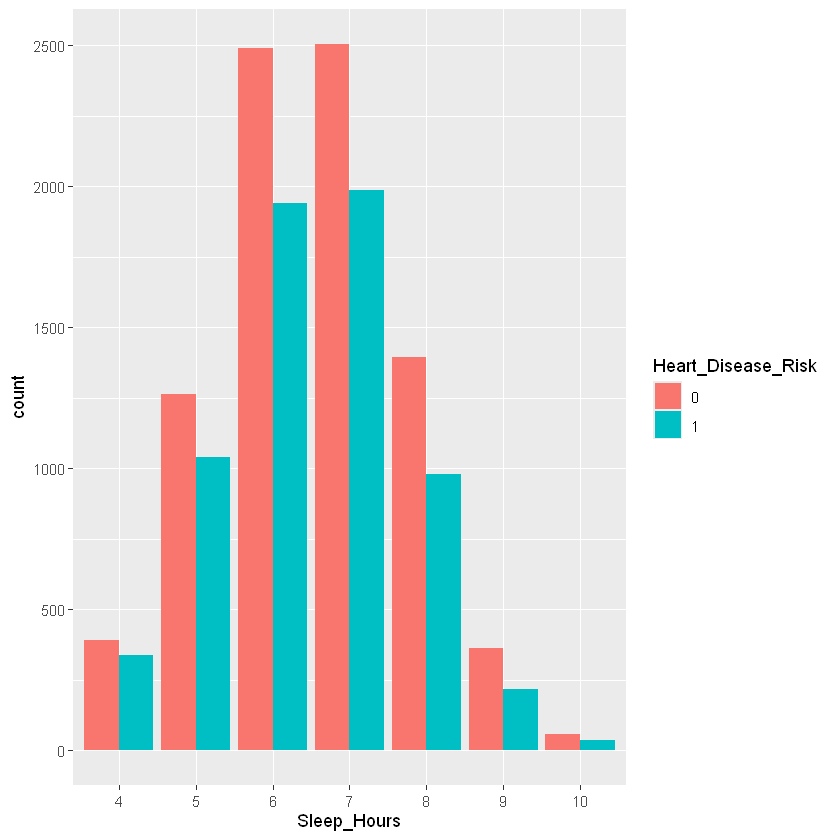

In [9]:
ggplot(data = data, aes(x=Sleep_Hours, fill=Heart_Disease_Risk))+ geom_bar(stat = 'count', position=position_dodge())

# Prepare data

In [10]:
# list of quantitative variable

numeric_cols <- names(data)[sapply(data, is.numeric)]
numeric_cols

[1] "Age"                 "Height_cm"           "Weight_kg"          
 [4] "BMI"                 "Systolic_BP"         "Diastolic_BP"       
 [7] "Cholesterol_Total"   "Cholesterol_LDL"     "Cholesterol_HDL"    
[10] "Fasting_Blood_Sugar" "Stress_Level"

In [11]:
# List of qualitative variables

categorical_cols <- names(data)[sapply(data, is.factor)]
categorical_cols

[1] "Gender"                  "Smoking_Status"         
[3] "Alcohol_Consumption"     "Physical_Activity_Level"
[5] "Family_History"          "Sleep_Hours"            
[7] "Heart_Disease_Risk"

**Important!!!**

We will use the function $\textit{createDataPartition}$ in the package $\textit{caret}$ to create the train data and test data. Before doing any analysis, we need to rescale the qualitative variables, since they have different scales.

In [12]:
library(caret)

Warning message:
"package 'caret' was built under R version 4.4.3"
Loading required package: lattice


Attaching package: 'caret'


The following object is masked from 'package:purrr':

    lift




In [13]:
#help(createDataPartition)

In [14]:
set.seed(111)
### Create dataset for Heart disease risk
train_id_H <- createDataPartition(data$Heart_Disease_Risk, p = 0.8, list = FALSE)
trainH <- data[train_id_H, ]
testH  <- data[-train_id_H, ]

# estimate scaling on training only
preproc <- preProcess(trainH[, numeric_cols], method = c("center", "scale"))

#apply the center and scale on the train and test data
train_scaledH <- predict(preproc, trainH)
test_scaledH  <- predict(preproc, testH)

In [15]:
dim(train_scaledH)
dim(test_scaledH)

[1] 12000    18

[1] 3000   18

In [16]:
summary(train_scaledH)
summary(test_scaledH)

      Age          Gender     Height_cm          Weight_kg      
 Min.   :-2.4949   0:6085   Min.   :-2.92900   Min.   :-2.6069  
 1st Qu.:-0.7210   1:5915   1st Qu.:-0.74765   1st Qu.:-0.7106  
 Median : 0.0392            Median :-0.06053   Median :-0.1020  
 Mean   : 0.0000            Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.: 0.7150            3rd Qu.: 0.73566   3rd Qu.: 0.6127  
 Max.   : 2.5733            Max.   : 3.53869   Max.   : 5.2970  
                                                                
      BMI            Systolic_BP         Diastolic_BP      Cholesterol_Total 
 Min.   :-3.12711   Min.   :-3.993653   Min.   :-3.60776   Min.   :-3.94837  
 1st Qu.:-0.70976   1st Qu.:-0.716731   1st Qu.:-0.65306   1st Qu.:-0.67555  
 Median :-0.05708   Median :-0.008207   Median : 0.05607   Median :-0.01214  
 Mean   : 0.00000   Mean   : 0.000000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.61978   3rd Qu.: 0.700317   3rd Qu.: 0.64701   3rd Qu.: 0.65127  
 Max.   : 4.

      Age             Gender     Height_cm           Weight_kg        
 Min.   :-2.4948786   0:1537   Min.   :-2.928998   Min.   :-2.939519  
 1st Qu.:-0.6576710   1:1463   1st Qu.:-0.758559   1st Qu.:-0.710566  
 Median :-0.0452685            Median :-0.087796   Median :-0.063108  
 Mean   : 0.0009362            Mean   :-0.009925   Mean   : 0.003791  
 3rd Qu.: 0.7149553            3rd Qu.: 0.713849   3rd Qu.: 0.640958  
 Max.   : 2.5732803            Max.   : 3.571411   Max.   : 3.782720  
                                                                      
      BMI            Systolic_BP         Diastolic_BP       Cholesterol_Total 
 Min.   :-2.93372   Min.   :-3.550826   Min.   :-3.607762   Min.   :-3.19651  
 1st Qu.:-0.68559   1st Qu.:-0.628165   1st Qu.:-0.653058   1st Qu.:-0.71978  
 Median :-0.05708   Median :-0.008207   Median : 0.056070   Median :-0.01214  
 Mean   : 0.01203   Mean   : 0.011071   Mean   : 0.009268   Mean   :-0.00586  
 3rd Qu.: 0.61978   3rd Qu.: 0.611751

# Heart disease risk

In order to compare the efficiency of each method, we need to find an indicator. For python the default score is the accuracy, i.e. (True pos + True neg)/total samples. However if we want to minimize the risk of saying a patient is healthy while he/she has a heart disease, we need to minimize false negative rate, i.e. maximize sensitivity (True pos / total real pos).

## Logistic regression

In [18]:
res.log = glm(Heart_Disease_Risk~., family="binomial", data=train_scaledH)

In [19]:
summary(res.log)


Call:
glm(formula = Heart_Disease_Risk ~ ., family = "binomial", data = train_scaledH)

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -0.167214   0.113769  -1.470  0.14162    
Age                       0.238227   0.026439   9.010  < 2e-16 ***
Gender1                  -0.077936   0.065133  -1.197  0.23148    
Height_cm                -0.114970   0.145361  -0.791  0.42899    
Weight_kg                 0.242453   0.237844   1.019  0.30802    
BMI                       0.001155   0.192751   0.006  0.99522    
Systolic_BP               0.340025   0.038523   8.826  < 2e-16 ***
Diastolic_BP             -0.008856   0.036748  -0.241  0.80957    
Cholesterol_Total        -0.046646   0.040699  -1.146  0.25175    
Cholesterol_LDL           0.208707   0.039065   5.343 9.16e-08 ***
Cholesterol_HDL          -0.057620   0.026062  -2.211  0.02704 *  
Fasting_Blood_Sugar       0.328689   0.022883  14.364  < 2e-16 ***
Smoking_Status1           

**Comment** : We can observe the significance of the parameters. It seems that the risk of having heart disease depends on Age, Systolic BP, Cholesterol_LDL, Fasting blood sugar, Smoking status, Physical activity level, Family history, Stress level and Sleep hours. This result is coherent with the exploratory analysis.

In [20]:
library(PRROC)
library(Metrics)

Warning message:
"package 'PRROC' was built under R version 4.4.3"
Loading required package: rlang


Attaching package: 'rlang'


The following objects are masked from 'package:purrr':

    %@%, flatten, flatten_chr, flatten_dbl, flatten_int, flatten_lgl,
    flatten_raw, invoke, splice


Warning message:
"package 'Metrics' was built under R version 4.4.3"

Attaching package: 'Metrics'


The following object is masked from 'package:rlang':

    ll


The following objects are masked from 'package:caret':

    precision, recall




       
           0    1
  FALSE 1398  491
  TRUE   294  817

[1] 0.6246177

[1] 0.7353735

[1] 0.6754857

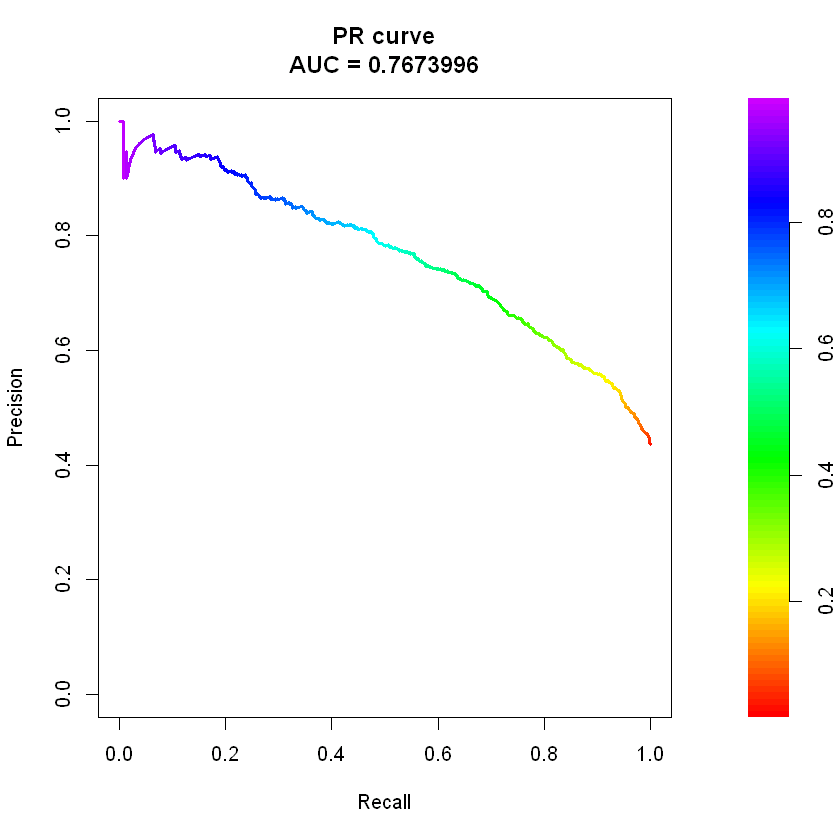

In [21]:
pred.log <- predict(res.log, newdata = test_scaledH, type = "response")
table(pred.log > 0.5, test_scaledH[, "Heart_Disease_Risk"])

#Recall
sum(pred.log >0.5 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.log >0.5 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.log >0.5)

#Fb score
y_true <- as.numeric(as.character(test_scaledH[, "Heart_Disease_Risk"]))
fbeta_score(y_true, pred.log >0.5, beta = 1)

#Plot the precision recall curve

plot(pr.curve(
  scores.class0 = pred.log,
  weights.class0 = y_true,
  curve = TRUE
))

In [22]:
score = c()
y_train = as.numeric(as.character(train_scaledH[, "Heart_Disease_Risk"]))
for (x in seq(0.1, 0.7, length.out = 50)){
    score = c(score,fbeta_score(y_train, res.log$fitted.values >x, beta = 1))
    print(c(x,fbeta_score(y_train, res.log$fitted.values >x, beta = 1)))
}

[1] 0.1000000 0.6364252
[1] 0.1122449 0.6412318
[1] 0.1244898 0.6471407
[1] 0.1367347 0.6541803
[1] 0.1489796 0.6607411
[1] 0.1612245 0.6668441
[1] 0.1734694 0.6725652
[1] 0.1857143 0.6759501
[1] 0.1979592 0.6803347
[1] 0.2102041 0.6853415
[1] 0.2224490 0.6897247
[1] 0.2346939 0.6940893
[1] 0.2469388 0.6975189
[1] 0.2591837 0.7003545
[1] 0.2714286 0.7030098
[1] 0.2836735 0.7062495
[1] 0.2959184 0.7073924
[1] 0.3081633 0.7096774
[1] 0.3204082 0.7099093
[1] 0.3326531 0.7070037
[1] 0.3448980 0.7085609
[1] 0.3571429 0.7071672
[1] 0.3693878 0.7071039
[1] 0.3816327 0.7072892
[1] 0.3938776 0.7061031
[1] 0.4061224 0.7061598
[1] 0.4183673 0.7061420
[1] 0.4306122 0.7023599
[1] 0.4428571 0.7002172
[1] 0.4551020 0.6958022
[1] 0.4673469 0.6936079
[1] 0.4795918 0.6914432
[1] 0.4918367 0.6882623
[1] 0.5040816 0.6834212
[1] 0.5163265 0.6806982
[1] 0.5285714 0.6752760
[1] 0.5408163 0.6690572
[1] 0.5530612 0.6638817
[1] 0.5653061 0.6585604
[1] 0.5775510 0.6505679
[1] 0.5897959 0.6446854
[1] 0.6020408 0.

In [23]:
seq(0.1, 0.7, length.out = 50)[which.max(score)]

[1] 0.3204082

In [24]:
p=seq(0.1, 0.7, length.out = 50)[which.max(score)]
#Recall
sum(pred.log >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.log >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.log >p)

#Fbeta score
fbeta_score(y_true, pred.log >p, beta = 1)

table(pred.log > p, test_scaledH[, "Heart_Disease_Risk"])

[1] 0.8142202

[1] 0.615963

[1] 0.70135

       
           0    1
  FALSE 1028  243
  TRUE   664 1065

### Logistic regression - AIC

In [25]:
#help(step)

In [26]:
res.log.aic = step(res.log, direction='backward')

Start:  AIC=12669.82
Heart_Disease_Risk ~ Age + Gender + Height_cm + Weight_kg + BMI + 
    Systolic_BP + Diastolic_BP + Cholesterol_Total + Cholesterol_LDL + 
    Cholesterol_HDL + Fasting_Blood_Sugar + Smoking_Status + 
    Alcohol_Consumption + Physical_Activity_Level + Family_History + 
    Stress_Level + Sleep_Hours

                          Df Deviance   AIC
- BMI                      1    12618 12668
- Diastolic_BP             1    12618 12668
- Alcohol_Consumption      2    12620 12668
- Height_cm                1    12618 12668
- Weight_kg                1    12619 12669
- Cholesterol_Total        1    12619 12669
- Gender                   1    12619 12669
<none>                          12618 12670
- Cholesterol_HDL          1    12623 12673
- Sleep_Hours              6    12639 12679
- Cholesterol_LDL          1    12646 12696
- Systolic_BP              1    12696 12746
- Age                      1    12700 12750
- Stress_Level             1    12796 12846
- Fasting_Blood_

       
           0    1
  FALSE 1398  490
  TRUE   294  818

[1] 0.6253823

[1] 0.7356115

[1] 0.6760331

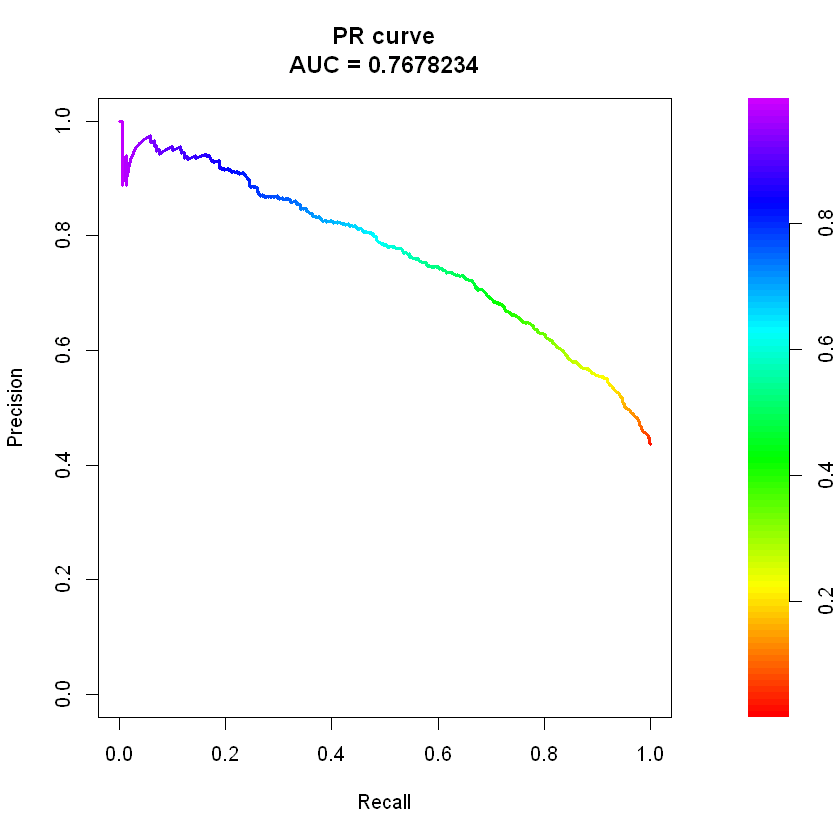

In [27]:
pred.log.aic <- predict(res.log.aic, newdata = test_scaledH, type = "response")
# Matrice de confusion pour la prévision du 
# dépassement de seuil
table(pred.log.aic > 0.5, test_scaledH[, "Heart_Disease_Risk"])

#Recall
sum(pred.log.aic >0.5 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.log.aic >0.5 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.log.aic >0.5)

#F beta score
fbeta_score(y_true, pred.log.aic >0.5, beta = 1)

plot(pr.curve(
  scores.class0 = pred.log.aic,
  weights.class0 = y_true,
  curve = TRUE
))

In [28]:
p=0.1
score = 0
for (x in seq(0.1, 0.7, length.out = 50)){
    if (score < fbeta_score(y_train, res.log.aic$fitted.values >x, beta = 1)){
        p = x
        score = fbeta_score(y_train, res.log.aic$fitted.values >x, beta = 1)
    }
}
p
#Recall
sum(pred.log.aic >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.log.aic >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.log >p)

#F betab score
score

table(pred.log.aic > p, test_scaledH[, "Heart_Disease_Risk"])

[1] 0.3081633

[1] 0.82263

[1] 0.6072235

[1] 0.7096982

       
           0    1
  FALSE 1001  232
  TRUE   691 1076

In [29]:
summary(res.log.aic)


Call:
glm(formula = Heart_Disease_Risk ~ Age + Height_cm + Weight_kg + 
    Systolic_BP + Cholesterol_LDL + Cholesterol_HDL + Fasting_Blood_Sugar + 
    Smoking_Status + Physical_Activity_Level + Family_History + 
    Stress_Level + Sleep_Hours, family = "binomial", data = train_scaledH)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -0.22975    0.10775  -2.132  0.03298 *  
Age                       0.23055    0.02565   8.989  < 2e-16 ***
Height_cm                -0.13914    0.02757  -5.048 4.47e-07 ***
Weight_kg                 0.24324    0.03040   8.002 1.23e-15 ***
Systolic_BP               0.33355    0.02478  13.459  < 2e-16 ***
Cholesterol_LDL           0.17316    0.02379   7.278 3.38e-13 ***
Cholesterol_HDL          -0.04713    0.02455  -1.919  0.05494 .  
Fasting_Blood_Sugar       0.32849    0.02287  14.362  < 2e-16 ***
Smoking_Status1           1.97834    0.04994  39.613  < 2e-16 ***
Physical_Activity_Level1 -0.58510  

In [30]:
anova(res.log.aic, test = "Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16438.38,NA
Age,1,341.4117701,11998,16096.97,3.143504e-76
Height_cm,1,0.4077415,11997,16096.56,5.231180e-01
Weight_kg,1,215.7135281,11996,15880.85,7.787776e-49
Systolic_BP,1,158.6956416,11995,15722.16,2.180931e-36
Cholesterol_LDL,1,43.1503646,11994,15679.00,5.069045e-11
Cholesterol_HDL,1,3.0627434,11993,15675.94,8.010631e-02
Fasting_Blood_Sugar,1,173.2186608,11992,15502.72,1.466278e-39
Smoking_Status,1,1640.2029765,11991,13862.52,0.000000e+00


In [31]:
# Test of sub model : verify if the submodel is efficient enough

anova(res.log.aic, res.log, test = "Chisq")

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,11980,12622.73,NA,NA,NA
2,11974,12617.82,6,4.914197,0.5548642


**Comment:** According to the submodel test, we conclude that we can replace the complete model by submodel.

In [32]:
# Odd ratio
as.table(exp(res.log.aic$coefficients))

             (Intercept)                      Age                Height_cm 
               0.7947297                1.2592933                0.8701036 
               Weight_kg              Systolic_BP          Cholesterol_LDL 
               1.2753799                1.3959173                1.1890552 
         Cholesterol_HDL      Fasting_Blood_Sugar          Smoking_Status1 
               0.9539669                1.3888697                7.2307199 
Physical_Activity_Level1 Physical_Activity_Level2 Physical_Activity_Level3 
               0.5570516                0.3281871                0.2083265 
         Family_History1             Stress_Level             Sleep_Hours5 
               4.3793332                1.3381101                0.9684577 
            Sleep_Hours6             Sleep_Hours7             Sleep_Hours8 
               0.8153382                0.8144013                0.7629508 
            Sleep_Hours9            Sleep_Hours10 
               0.6132719             

**Comments:**
- A smoking person can have about 7 times higher risk of having cardiovascular diseases compared to non-smoking person.
- For a person which family history had a heart disease patient, the odds of having the disease is about 4 times higher than those not having any in the family history.
- The stress level increases the risk, while the sleep hour reduces it.
- ...

In [33]:
library(ROCR)

Warning message:
"package 'ROCR' was built under R version 4.4.3"


In [34]:
roclogit <- predict(res.log.aic, newdata = test_scaledH, type="response")
predlogit <- prediction(roclogit, test_scaledH[, "Heart_Disease_Risk"])
perflogit <- performance(predlogit, "tpr", "fpr")

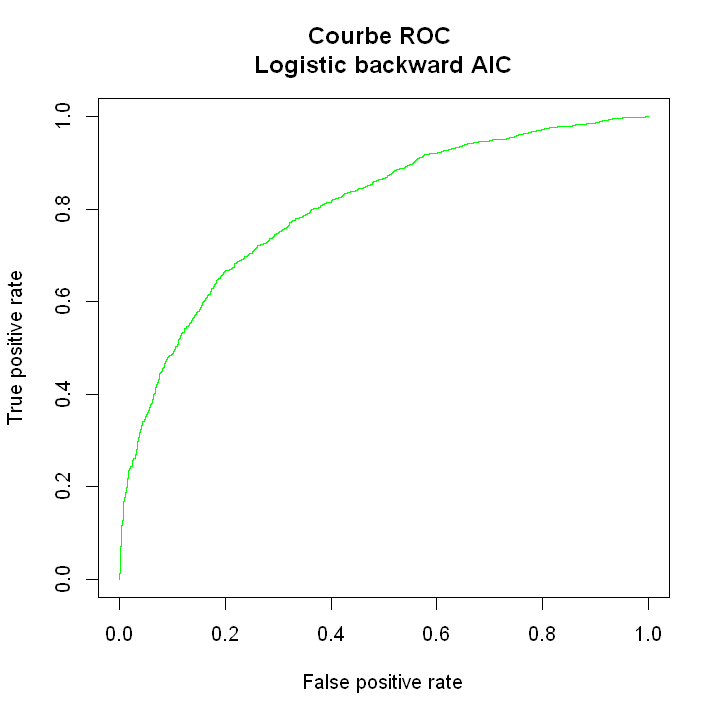

In [35]:
options(repr.plot.width = 6, repr.plot.height = 6)
plot(perflogit,col="green",lty=1, main = "Courbe ROC \n Logistic backward AIC ") 

## LDA

In [36]:
library(glmnet)
library(MASS)

Warning message:
"package 'glmnet' was built under R version 4.4.3"
Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Loaded glmnet 4.1-10

Warning message:
"package 'MASS' was built under R version 4.4.3"

Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select




In [37]:
res.lda <- lda(Heart_Disease_Risk~., data=train_scaledH)
res.lda

Call:
lda(Heart_Disease_Risk ~ ., data = train_scaledH)

Prior probabilities of groups:
    0     1 
0.564 0.436 

Group means:
         Age   Gender1    Height_cm   Weight_kg        BMI Systolic_BP
0 -0.1473106 0.4946809 -0.004046744 -0.09820723 -0.1186026  -0.1701976
1  0.1905578 0.4906346  0.005234779  0.12703871  0.1534217   0.2201639
  Diastolic_BP Cholesterol_Total Cholesterol_LDL Cholesterol_HDL
0   -0.1355837        -0.1189381      -0.1184874      0.05416145
1    0.1753880         0.1538557       0.1532726     -0.07006205
  Fasting_Blood_Sugar Smoking_Status1 Alcohol_Consumption1 Alcohol_Consumption2
0          -0.1452366       0.1619385            0.4026300            0.1022459
1           0.1878749       0.4894878            0.3881881            0.1041667
  Physical_Activity_Level1 Physical_Activity_Level2 Physical_Activity_Level3
0                0.3863771                0.3345154               0.12470449
1                0.4241208                0.2450306               0.06

In [38]:
pred.lda <- predict(res.lda, test_scaledH)
table(pred.lda$class, test_scaledH[, "Heart_Disease_Risk"])

# Recall
sum(pred.lda$class == 1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.lda$class == 1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.lda$class == 1)

#F beta score
fbeta_score(y_true, pred.lda$class ==1, beta = 2)

   
       0    1
  0 1403  504
  1  289  804

[1] 0.6146789

[1] 0.7355901

[1] 0.6355731

In [39]:
p=0.1
score = 0
for (x in seq(0.1, 0.7, length.out = 50)){
    if (score < fbeta_score(y_train, predict(res.lda, train_scaledH)$posterior[,2] >x, beta = 1)){
        p = x
        score = fbeta_score(y_train, predict(res.lda, train_scaledH)$posterior[,2] >x, beta = 1)
    }
}
#Recall
sum(pred.lda$posterior[,2] >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.lda$posterior[,2] >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.lda$posterior[,2] >p)

#F beta score
score

table(pred.lda$posterior[,2] > p, test_scaledH[, "Heart_Disease_Risk"])

[1] 0.808104

[1] 0.6184903

[1] 0.7087817

       
           0    1
  FALSE 1040  251
  TRUE   652 1057

## Compare Precision-recall curve

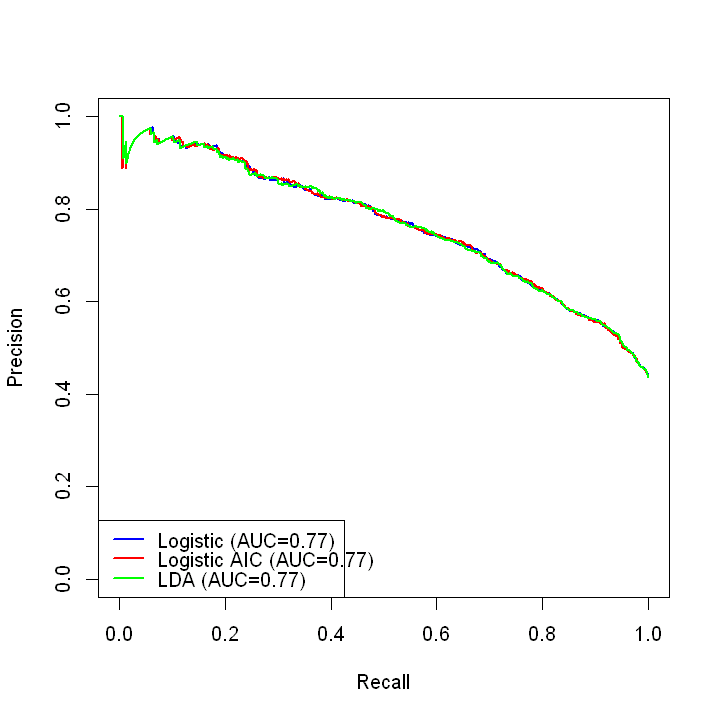

In [40]:
pred.log <- predict(res.log, newdata = test_scaledH, type = "response")
pred.log.aic <- predict(res.log.aic, newdata = test_scaledH, type = "response")
pred.lda <- predict(res.lda, newdata = test_scaledH, type = "response")$posterior[,2]

pr1 = pr.curve(
  scores.class0 = pred.log,
  weights.class0 = y_true,
  curve = TRUE
)

pr2 = pr.curve(
  scores.class0 = pred.log.aic,
  weights.class0 = y_true,
  curve = TRUE
)

pr3 = pr.curve(
  scores.class0 = pred.lda,
  weights.class0 = y_true,
  curve = TRUE
)

plot(pr1$curve[,1], pr1$curve[,2],
     type = "l", col = "blue", lwd = 2,
     xlab = "Recall", ylab = "Precision",
     xlim = c(0,1), ylim = c(0,1))

lines(pr2$curve[,1], pr2$curve[,2], col = "red", lwd = 2)
lines(pr3$curve[,1], pr3$curve[,2], col = "green", lwd = 2)

legend("bottomleft",
       legend = c(
         paste0("Logistic (AUC=", round(pr1$auc.integral,2), ")"),
         paste0("Logistic AIC (AUC=", round(pr2$auc.integral,2), ")"),
        paste0("LDA (AUC=", round(pr3$auc.integral,2), ")")
       ),
       col = c("blue", "red", "green"),
       lwd = 2)

## PLS - DA

In [41]:
library(mdatools)

Warning message:
"package 'mdatools' was built under R version 4.4.3"
Registered S3 methods overwritten by 'mdatools':
  method        from 
  predict.plsda caret
  print.plsda   caret


Attaching package: 'mdatools'


The following object is masked from 'package:caret':

    plsda




In [42]:
X <- model.matrix(Heart_Disease_Risk ~ . , data = train_scaledH)[, -1]
y <- train_scaledH$Heart_Disease_Risk
res.plsda = plsda(X,y, ncomp=10)

Warning message in selectCompNum.pls(model, selcrit = ncomp.selcrit):
"No validation results were found."


In [43]:
summary(res.plsda)


PLS-DA model (class plsda) summary
------------------------------------
Info: 
Number of selected components: 10
Cross-validation: none

Class #1 (0)
    X cumexpvar Y cumexpvar   TP   FP   TN   FN Spec. Sens. Accuracy
Cal       78.66        27.8 5532 1895 3337 1236 0.638 0.817    0.739

Class #2 (1)
    X cumexpvar Y cumexpvar   TP   FP   TN   FN Spec. Sens. Accuracy
Cal       78.66        27.8 3337 1236 5532 1895 0.817 0.638    0.739



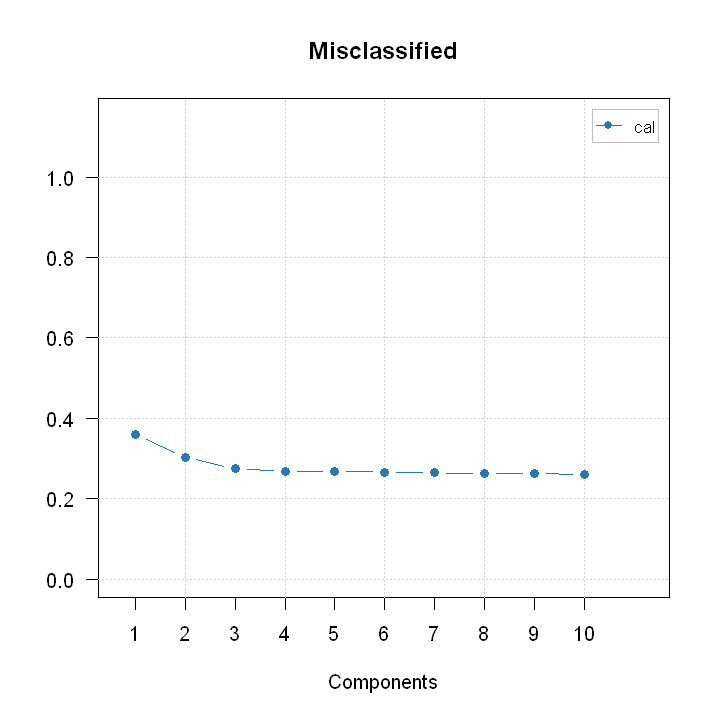

In [44]:
plotMisclassified(res.plsda)

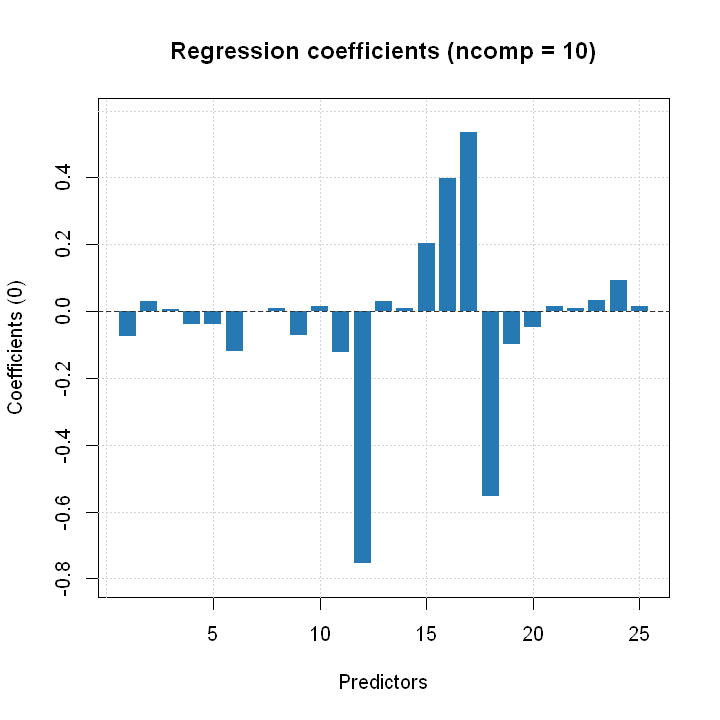

In [45]:
plotRegcoeffs(res.plsda)

In [46]:
pred.plsda = predict(res.plsda,  model.matrix(Heart_Disease_Risk ~ . , data = test_scaledH)[, -1], c.ref=test_scaledH$Heart_Disease_Risk)

In [47]:
table(pred.plsda$c.pred[, 3,2], test_scaledH[, "Heart_Disease_Risk"])

    
        0    1
  -1 1370  518
  1   322  790

In [48]:
sum(pred.plsda$c.pred[, 3,2]==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.plsda$c.pred[, 3,2]==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.plsda$c.pred[, 3,2]==1)

#F beta score
fbeta_score(y_true, pred.plsda$c.pred[, 3,2]==1, beta = 1)

[1] 0.6039755

[1] 0.7104317

[1] 0.6528926

In [49]:
p=-1
score = 0
nc = 1
pred_train = predict(res.plsda,  model.matrix(Heart_Disease_Risk ~ . , data = train_scaledH)[, -1], c.ref=train_scaledH$Heart_Disease_Risk)
for (x in seq(-0.6, 0.6, length.out = 50)){
    for (i in 1:10){
        if (score < fbeta_score(y_train, pred_train$y.pred[, i,2]>x, beta = 1)){
            p = x
            nc = i
            score = fbeta_score(y_train, pred_train$y.pred[, i,2]>x, beta = 1)
        }
    }
}
p
nc
#Recall
sum(pred.plsda$y.pred[, nc,2] >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.plsda$y.pred[, nc,2] >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.plsda$y.pred[, nc,2] >p)

#F beta score
score

table(pred.plsda$y.pred[, nc,2] > p, test_scaledH[, "Heart_Disease_Risk"])

[1] -0.2816327

[1] 10

[1] 0.8050459

[1] 0.6219728

[1] 0.709587

       
           0    1
  FALSE 1052  255
  TRUE   640 1053

## SVM

In [50]:
library(e1071) #kernel svm
library(LiblineaR) #linear svm

Warning message:
"package 'e1071' was built under R version 4.4.3"

Attaching package: 'e1071'


The following object is masked from 'package:ggplot2':

    element


Warning message:
"package 'LiblineaR' was built under R version 4.4.3"


### Linear SVM

In [51]:
# Custom summary function for F-beta
fbeta_summary <- function(data, lev = NULL, model = NULL) {
  # Change beta to 1 for F1-score, or 2 to prioritize recall
  beta <- 1 
  
  # Calculate Precision and Recall using caret's built-in tools
  precision <- posPredValue(data$pred, data$obs, positive = lev[2])
  recall <- sensitivity(data$pred, data$obs, positive = lev[2])
  
  # Calculate F-beta
  f_beta <- (1 + beta^2) * (precision * recall) / ((beta^2 * precision) + recall)
  
  # If F-beta is NaN (e.g., zero precision/recall), return 0
  if (is.na(f_beta)) f_beta <- 0
  
  names(f_beta) <- "Fbeta"
  return(f_beta)
}

In [52]:
train_ctrl <- trainControl(
  method = "cv",               # Cross-validation
  number = 5,                  # 5-fold CV
  summaryFunction = fbeta_summary, 
  classProbs = TRUE,     
  savePredictions = "final"
)

In [53]:
levels(train_scaledH$Heart_Disease_Risk) <- c("NoRisk", "Risk")
weight_ratios <- c(1, 2, 3,4,5)
results_df <- data.frame()
set.seed(123)
for(w in weight_ratios){
  model <- train(Heart_Disease_Risk ~ ., data = train_scaledH,
                 method = "svmLinear3",
                 metric = "Fbeta",
                 trControl = train_ctrl,
                 tuneGrid = expand.grid(cost = c(1, 1.5, 2, 2.5, 3, 3.5), Loss = "L2_primal"),
                 wi = c("NoRisk" = 1, "Risk" = w))
  res <- model$results
  res$weight_ratio <- w
  results_df <- rbind(results_df, res)}

levels(train_scaledH$Heart_Disease_Risk) <- c(0, 1)

Warning message in train.default(x, y, weights = w, ...):
"Class probabilities were requested for a model that does not implement them"
Warning message in train.default(x, y, weights = w, ...):
"Class probabilities were requested for a model that does not implement them"
Warning message in train.default(x, y, weights = w, ...):
"Class probabilities were requested for a model that does not implement them"
Warning message in train.default(x, y, weights = w, ...):
"Class probabilities were requested for a model that does not implement them"
Warning message in train.default(x, y, weights = w, ...):
"Class probabilities were requested for a model that does not implement them"


In [54]:
best_idx <- order(-results_df$Fbeta)[1]
best_params <- results_df[best_idx, ]

print("Best Parameters Found:")
print(best_params)

[1] "Best Parameters Found:"
   cost      Loss     Fbeta     FbetaSD weight_ratio
10  2.5 L2_primal 0.7078167 0.007969312            2


In [55]:
x_train <- as.matrix(train_scaledH[, -which(names(train_scaledH) == "Heart_Disease_Risk")])
y_train <- train_scaledH$Heart_Disease_Risk

# 2. Define the best weights based on your tuning (Weight Ratio = 2)
# This assumes your levels are "NoRisk" and "Risk"
final_weights <- c("0" = 1, "1" = 2)

# 3. Build the final model
# type = 1 is L2-regularized L2-loss SVC (primal), which matches your "L2_primal"
svm.lin <- LiblineaR(
  data = x_train, 
  target = y_train, 
  type = 1, 
  cost = 2.5, 
  wi = final_weights,
  verbose = FALSE
)

# 4. Save/Inspect the model
summary(svm.lin)

           Length Class  Mode     
TypeDetail  1     -none- character
Type        1     -none- numeric  
W          18     -none- numeric  
Bias        1     -none- numeric  
ClassNames  2     factor numeric  
NbClass     1     -none- numeric  

In [56]:
pred.svm.lin <- predict(svm.lin, test_scaledH[,-18])$predictions
table(pred.svm.lin, test_scaledH[, "Heart_Disease_Risk"])
#Recall
sum(pred.svm.lin==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.svm.lin==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.svm.lin==1)

#F beta score
fbeta_score(y_true, pred.svm.lin==1, beta = 1)

            
pred.svm.lin    0    1
           0 1177  320
           1  515  988

[1] 0.7553517

[1] 0.657352

[1] 0.7029527

**TODO** kernel SVM

### kernel SVM

In [88]:
model = svm(Heart_Disease_Risk ~ ., data = train_scaledH, type = "C")

In [89]:
pred.svm.lin <- predict(model, test_scaledH[,-18])
table(pred.svm.lin, test_scaledH[, "Heart_Disease_Risk"])
#Recall
sum(pred.svm.lin==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.svm.lin==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.svm.lin==1)

#F beta score
fbeta_score(y_true, pred.svm.lin==1, beta = 1)

            
pred.svm.lin    0    1
           0 1409  524
           1  283  784

[1] 0.5993884

[1] 0.7347704

[1] 0.6602105

In [90]:
library(kernlab)

# Prepare your X data (exclude the target variable)
x_data <- as.matrix(train_scaledH[, -which(names(train_scaledH) == "Heart_Disease_Risk")])

# Estimate the sigma values
sig_estimates <- sigest(Heart_Disease_Risk ~ ., data = train_scaledH, na.action = na.omit)

# View the suggested range
print(sig_estimates)

# Use these for your tuneGrid
# 90% of the time, the best sigma is between the 'bottom' and 'top' estimates
my_sigma_range <- as.numeric(sig_estimates)


Attaching package: 'kernlab'


The following object is masked from 'package:purrr':

    cross


The following object is masked from 'package:ggplot2':

    alpha




       90%        50%        10% 
0.02341869 0.04119333 0.07412997 


In [ ]:
# Define a grid based on the estimates
levels(train_scaledH$Heart_Disease_Risk) <- c("NoRisk", "Risk")
tune_grid <- expand.grid(
  sigma = my_sigma_range,     # Uses the 3 values suggested by sigest
  C = c(1,1.5, 2, 2.5, 3)       # Standard range for Cost
)

weight_ratios <- c(1, 2, 5)
kernel_results <- data.frame()

for (w in weight_ratios) {
  set.seed(123)
  
  # Note: kernlab (svmRadial) uses 'class.weights' argument
  curr_weights <- c("NoRisk" = 1, "Risk" = w)
  
  temp_model <- train(
    Heart_Disease_Risk ~ ., 
    data = train_scaledH,
    method = "svmRadial",
    metric = "Fbeta",
    trControl = trainControl(method = "cv", number = 5, 
                             summaryFunction = fbeta_summary, 
                             classProbs = TRUE),
    tuneGrid = tune_grid,
    class.weights = curr_weights
  )
  
  res <- temp_model$results
  res$weight_ratio <- w
  kernel_results <- rbind(kernel_results, res)
}
levels(train_scaledH$Heart_Disease_Risk) <- c(0, 1)

In [57]:
library(liquidSVM)

ERROR: Error in library(liquidSVM): there is no package called 'liquidSVM'


In [ ]:
levels(train_scaledH$Heart_Disease_Risk) <- c("NoRisk", "Risk")
tune_grid <- expand.grid(
  sigma = my_sigma_range,     # Uses the 3 values suggested by sigest
  C = c(1,1.5, 2, 2.5, 3)       # Standard range for Cost
)
temp_model <- train(
    Heart_Disease_Risk ~ ., 
    data = train_scaledH,
    method = "svmRadial",
    metric = "Fbeta",
    trControl = trainControl(method = "cv", number = 5, 
                             summaryFunction = fbeta_summary, 
                             classProbs = TRUE),
    tuneGrid = tune_grid,
    class.weights = curr_weights
  )

## Tree

In [178]:
library(rpart) 

In [179]:
train_scaledH$Heart_Disease_Risk <- as.factor(train_scaledH$Heart_Disease_Risk)
tree.dis=rpart(Heart_Disease_Risk ~ ., data = train_scaledH,cp=0.001,parms=list(split="information"))

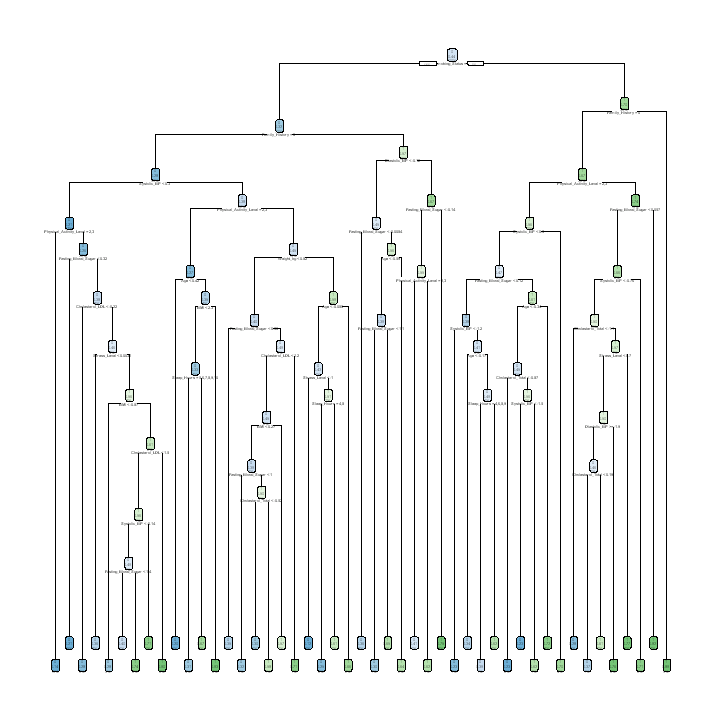

In [180]:
library(rpart.plot)
rpart.plot(tree.dis)

In [181]:
xmat <- xpred.rpart(tree.dis)

xmat01 <- xmat - 1
true_labels01 <- as.numeric(as.character(train_scaledH$Heart_Disease_Risk))

CVerr <- apply(xmat01, 2, function(column) {
  fbeta_score(true_labels01, column, beta = 1)
})

CVerr

0.640003823 0.097052653 0.018459781 0.007871277 0.005618096 0.004965742 
        NaN   0.5762178   0.6457532   0.6274428   0.6377255   0.6409203 
0.004379373 0.003611323 0.003000825 0.002521198 0.001986297 0.001671718 
  0.6574541   0.6546012   0.6553580   0.6523253   0.6531656   0.6523649 
0.001509011 0.001369405 0.001238674 0.001114479 0.001040711 
  0.6519348   0.6543546   0.6538539   0.6548351   0.6553945

In [182]:
tree.dis=rpart(Heart_Disease_Risk ~ ., data = train_scaledH,parms=list(split="information"),cp=as.numeric(attributes(which.max(CVerr))$names))

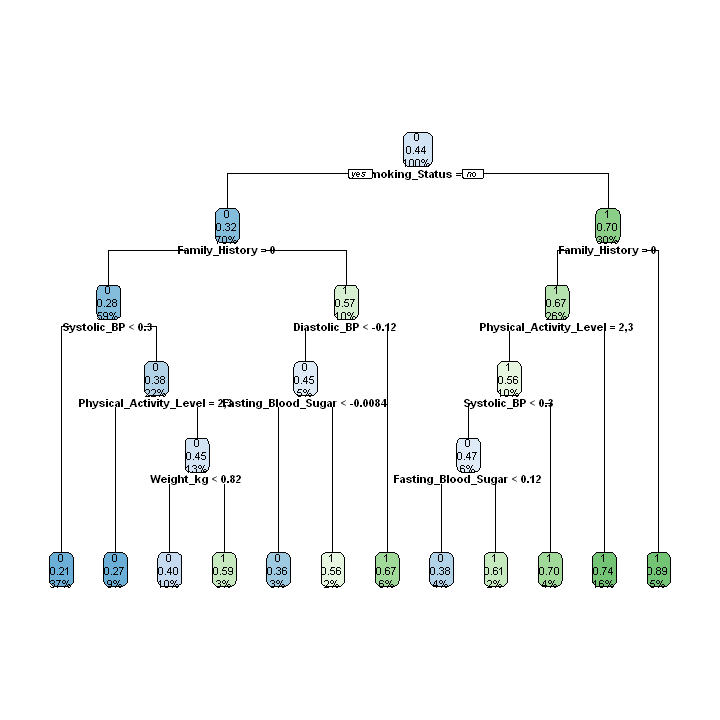

In [183]:
rpart.plot(tree.dis)

In [184]:
pred.treeq=predict(tree.dis,newdata=test_scaledH,type="class")
  #table(pred.treeq,datestq[,"DepSeuil"])
confusionMatrix(pred.treeq,test_scaledH$Heart_Disease_Risk)$table

          Reference
Prediction    0    1
         0 1372  547
         1  320  761

## Random Forest

In [185]:
library(randomForest)

In [186]:
?randomForest

randomForest {randomForest},R Documentation
data,an optional data frame containing the variables in the model. By default the variables are taken from the environment which randomForest is called from.
subset,"an index vector indicating which rows should be used. (NOTE: If given, this argument must be named.)"
na.action,"A function to specify the action to be taken if NAs are found. (NOTE: If given, this argument must be named.)"
"x, formula","a data frame or a matrix of predictors, or a formula describing the model to be fitted (for the print method, an randomForest object)."
y,"A response vector. If a factor, classification is assumed, otherwise regression is assumed. If omitted, randomForest will run in unsupervised mode."
xtest,a data frame or matrix (like x) containing predictors for the test set.
ytest,response for the test set.
ntree,"Number of trees to grow. This should not be set to too small a number, to ensure that every input row gets predicted at least a few times."
mtry,Number of variables randomly sampled as candidates at each split. Note that the default values are different for classification (sqrt(p) where p is number of variables in x) and regression (p/3)
weights,A vector of length same as y that are positive weights used only in sampling data to grow each tree (not used in any other calculation)


In [187]:
# TODO : Change the parameter
res.forest = randomForest(Heart_Disease_Risk ~ ., data = train_scaledH, xtest = test_scaledH[,-18], 
                          ytest = test_scaledH$Heart_Disease_Risk,ntree=500,do.trace=50,importance=TRUE,
                         classwt = c(1, 2))
res.forest$importance

ntree      OOB      1      2|    Test      1      2
   50:  28.55% 19.08% 40.81%|  27.97% 16.19% 43.20%
  100:  27.63% 18.03% 40.06%|  27.90% 15.54% 43.88%
  150:  27.45% 17.69% 40.08%|  27.77% 15.25% 43.96%
  200:  27.27% 17.52% 39.89%|  27.77% 15.13% 44.11%
  250:  27.43% 17.60% 40.14%|  27.70% 15.48% 43.50%
  300:  27.32% 17.48% 40.04%|  27.53% 15.01% 43.73%
  350:  27.30% 17.42% 40.08%|  27.33% 15.01% 43.27%
  400:  27.28% 17.58% 39.83%|  27.33% 14.89% 43.43%
  450:  27.23% 17.46% 39.87%|  27.33% 14.95% 43.35%
  500:  27.30% 17.57% 39.89%|  27.33% 14.95% 43.35%


,0,1,MeanDecreaseAccuracy,MeanDecreaseGini
Age,3.851703e-03,0.0087201416,0.0059704954,391.10382
Gender,-2.531888e-04,0.0020071467,0.0007286833,43.82891
Height_cm,-6.192267e-04,0.0060198093,0.0022772121,368.07491
Weight_kg,-2.907619e-03,0.0164772650,0.0055463046,380.75168
BMI,-1.365470e-03,0.0145190150,0.0055618481,382.08690
Systolic_BP,3.973122e-03,0.0202166595,0.0110493860,402.83904
Diastolic_BP,-7.013087e-04,0.0113634325,0.0045616038,331.27159
Cholesterol_Total,-2.554213e-03,0.0117536622,0.0036892451,364.07399
Cholesterol_LDL,-2.164583e-03,0.0135644861,0.0046961721,364.03268
Cholesterol_HDL,-9.078825e-04,0.0028516737,0.0007323465,302.73361


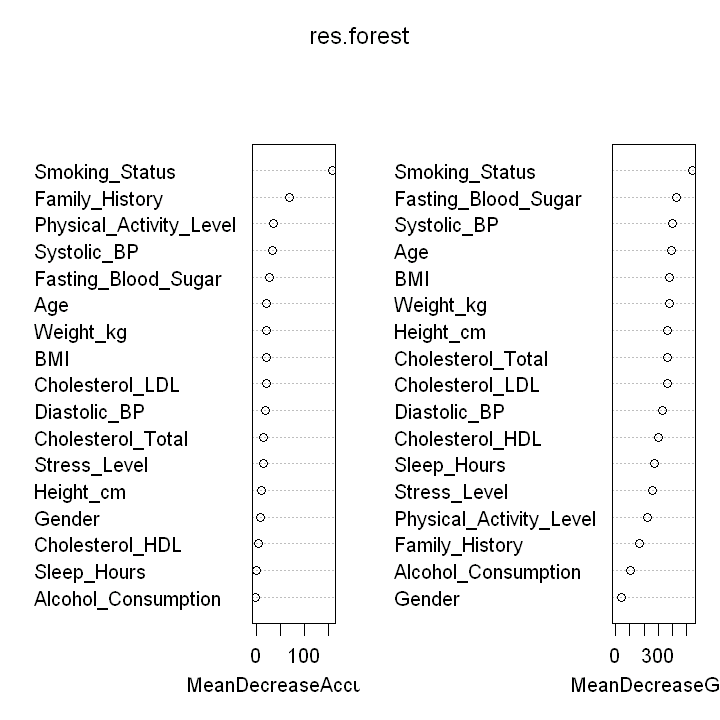

In [188]:
varImpPlot(res.forest)

In [189]:
pred.forest <- res.forest$test$predicted
table(pred.forest, test_scaledH[, "Heart_Disease_Risk"])
#Recall
sum(pred.forest==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(pred.forest==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.forest==1)

#F beta score
fbeta_score(y_true, pred.forest==1, beta = 1)

           
pred.forest    0    1
          0 1439  567
          1  253  741

[1] 0.5665138

[1] 0.7454728

[1] 0.643788

In [190]:
res.forest$importance

,0,1,MeanDecreaseAccuracy,MeanDecreaseGini
Age,3.851703e-03,0.0087201416,0.0059704954,391.10382
Gender,-2.531888e-04,0.0020071467,0.0007286833,43.82891
Height_cm,-6.192267e-04,0.0060198093,0.0022772121,368.07491
Weight_kg,-2.907619e-03,0.0164772650,0.0055463046,380.75168
BMI,-1.365470e-03,0.0145190150,0.0055618481,382.08690
Systolic_BP,3.973122e-03,0.0202166595,0.0110493860,402.83904
Diastolic_BP,-7.013087e-04,0.0113634325,0.0045616038,331.27159
Cholesterol_Total,-2.554213e-03,0.0117536622,0.0036892451,364.07399
Cholesterol_LDL,-2.164583e-03,0.0135644861,0.0046961721,364.03268
Cholesterol_HDL,-9.078825e-04,0.0028516737,0.0007323465,302.73361


**Comments** For the random forest, the role of physical activity level, family history and stress level decreases.

In [191]:
score = c()
for (x in seq(0.1, 0.7, length.out = 50)){
    score = c(score,fbeta_score(y_train, res.forest$votes[,2] >x, beta = 1))
    print(c(x,fbeta_score(y_train, res.forest$votes[,2] >x, beta = 1)))
}

[1] 0.1000000 0.6240452
[1] 0.1122449 0.6287939
[1] 0.1244898 0.6332122
[1] 0.1367347 0.6381279
[1] 0.1489796 0.6435036
[1] 0.1612245 0.6473157
[1] 0.1734694 0.6534265
[1] 0.1857143 0.6592238
[1] 0.1979592 0.6624797
[1] 0.2102041 0.6675822
[1] 0.2224490 0.6726815
[1] 0.2346939 0.6765271
[1] 0.2469388 0.6805737
[1] 0.2591837 0.6815362
[1] 0.2714286 0.6823883
[1] 0.2836735 0.6846089
[1] 0.2959184 0.6899346
[1] 0.3081633 0.6909380
[1] 0.3204082 0.6945119
[1] 0.3326531 0.6960323
[1] 0.3448980 0.6993937
[1] 0.3571429 0.6975865
[1] 0.3693878 0.6963506
[1] 0.3816327 0.6948474
[1] 0.3938776 0.6905042
[1] 0.4061224 0.6916490
[1] 0.4183673 0.6906502
[1] 0.4306122 0.6854746
[1] 0.4428571 0.6817610
[1] 0.4551020 0.6763808
[1] 0.4673469 0.6712082
[1] 0.4795918 0.6673457
[1] 0.4918367 0.6600393
[1] 0.5040816 0.6554587
[1] 0.5163265 0.6477005
[1] 0.5285714 0.6401915
[1] 0.5408163 0.6313578
[1] 0.5530612 0.6250281
[1] 0.5653061 0.6155076
[1] 0.5775510 0.6053302
[1] 0.5897959 0.5946010
[1] 0.6020408 0.

In [192]:
p=seq(0.1, 0.7, length.out = 50)[which.max(score)]
#Recall
sum(res.forest$test$votes[,2] >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1)

#Precision
sum(res.forest$test$votes[,2] >p & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(res.forest$test$votes[,2] >p)

#Fbeta score
fbeta_score(y_true, res.forest$test$votes[,2] >p, beta = 1)

table(res.forest$test$votes[,2] > p, test_scaledH[, "Heart_Disease_Risk"])

[1] 0.7798165

[1] 0.6292412

[1] 0.6964834

       
           0    1
  FALSE 1091  288
  TRUE   601 1020